<a href="https://colab.research.google.com/github/fcoliveira-utfpr/climas_brasil/blob/main/municipios_brasil_ibge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Municípios do Brasil — Código IBGE, Atributos e Centroide (Lat/Lon)

Este notebook monta uma tabela completa com todos os municípios brasileiros contendo:

- Código IBGE (7 dígitos)
- Nome do município
- UF (sigla e nome)
- Região (sigla e nome)
- Mesorregião e microrregião
- Região geográfica imediata e intermediária (divisão regional 2017 do IBGE)
- Latitude e longitude do centroide do município

**Fontes de dados:**
1. **Malha geoespacial**: pacote [`geobr`](https://github.com/ipeaGIT/geobr) (IBGE, malha 2025 — a mais atual disponível no pacote)
2. **Atributos administrativos**: [API de Localidades do IBGE](https://servicodados.ibge.gov.br/api/docs/localidades) (dados sempre atualizados em tempo real, direto do IBGE)

O centroide é calculado em projeção métrica (SIRGAS 2000 / Brasil Polyconic, EPSG:5880) e depois convertido de volta para WGS84 (EPSG:4326), garantindo precisão geométrica adequada mesmo para municípios grandes ou com geometria irregular.

## 1. Instalação e importação dos pacotes

In [1]:
!pip install -q geobr geopandas   -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.7/341.7 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 70.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 97.6 MB/s eta 0:00:00


In [2]:
import geobr
import geopandas as gpd
import pandas as pd
import requests

pd.set_option("display.max_columns", None)

## 2. Parâmetros

In [3]:
# Ano da malha municipal do geobr (2025 é a versão mais recente disponível no pacote no momento)
ANO_MALHA = 2025

# simplified=False mantém a geometria original do IBGE (maior precisão de centroide,
# porém download mais pesado e mais lento). Use True para agilidade se a precisão
# geométrica milimétrica não for crítica.
MALHA_SIMPLIFICADA = False

## 3. Malha geoespacial dos municípios (geobr)

In [4]:
gdf = geobr.read_municipality(
    code_muni="all",
    year=ANO_MALHA,
    simplified=MALHA_SIMPLIFICADA
)

gdf = gdf.rename(columns={"code_muni": "codigo_ibge"})
gdf["codigo_ibge"] = gdf["codigo_ibge"].astype(int).astype(str)

print(f"Total de municípios na malha: {len(gdf)}")
gdf.head()

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
municipalities_2025.parquet: 100%|██████████| 318M/318M [00:04<00:00, 64.1MB/s]


Total de municípios na malha: 5571


,codigo_ibge,name_muni,code_state,abbrev_state,name_state,code_region,name_region,year,geometry
0,1100015,Alta Floresta d'Oeste,11.0,RO,Rondônia,1.0,Norte,2025.0,"MULTIPOLYGON (((-62.24906 -13.06005, -62.24935..."
1,1100023,Ariquemes,11.0,RO,Rondônia,1.0,Norte,2025.0,"MULTIPOLYGON (((-62.6992 -10.2668, -62.70126 -..."
2,1100031,Cabixi,11.0,RO,Rondônia,1.0,Norte,2025.0,"MULTIPOLYGON (((-60.77041 -13.66746, -60.77053..."
3,1100049,Cacoal,11.0,RO,Rondônia,1.0,Norte,2025.0,"MULTIPOLYGON (((-61.05082 -11.42227, -61.05118..."
4,1100056,Cerejeiras,11.0,RO,Rondônia,1.0,Norte,2025.0,"MULTIPOLYGON (((-60.95055 -13.32637, -60.95053..."


## 4. Cálculo do centroide (projeção métrica → WGS84)

Observação: para municípios com geometria muito irregular (ex.: litorâneos com ilhas, arquipélagos), o centroide geométrico pode cair fora do polígono principal (ex.: no mar). Caso isso seja um problema para o seu uso (ex.: extração de dados climáticos em grade), troque `.centroid` por `.representative_point()`, que garante um ponto sempre dentro do polígono, ao custo de não ser exatamente o centro de massa.

In [7]:
# Reprojeta para CRS métrico (SIRGAS 2000 / Brasil Polyconic) antes de calcular o centroide
gdf_proj = gdf.to_crs(epsg=5880)

centroides_proj = gdf_proj.geometry.centroid
centroides_wgs84 = gpd.GeoSeries(centroides_proj.values, crs=5880).to_crs(epsg=4326)

gdf["longitude"] = centroides_wgs84.x.values
gdf["latitude"] = centroides_wgs84.y.values

gdf[["codigo_ibge", "name_muni", "abbrev_state", "latitude", "longitude"]].head()

,codigo_ibge,name_muni,abbrev_state,latitude,longitude
0,1100015,Alta Floresta d'Oeste,RO,-12.469788,-62.274391
1,1100023,Ariquemes,RO,-9.951936,-62.957505
2,1100031,Cabixi,RO,-13.474909,-60.639773
3,1100049,Cacoal,RO,-11.301321,-61.324675
4,1100056,Cerejeiras,RO,-13.203692,-61.261150


## 5. Atributos administrativos via API de Localidades do IBGE

A API pública do IBGE devolve, para cada município, a hierarquia completa: microrregião, mesorregião, UF, região, além da divisão regional mais recente (regiões geográficas imediata e intermediária, instituída em 2017).

In [8]:
url = "https://servicodados.ibge.gov.br/api/v1/localidades/municipios"
resp = requests.get(url, timeout=60)
resp.raise_for_status()
municipios_api = resp.json()

print(f"Total de municípios retornados pela API: {len(municipios_api)}")

Total de municípios retornados pela API: 5571


In [9]:
registros = []

for m in municipios_api:
    micro = m.get("microrregiao") or {}
    meso = micro.get("mesorregiao") or {}
    uf = meso.get("UF") or {}
    regiao = uf.get("regiao") or {}

    reg_imediata = m.get("regiao-imediata") or {}
    reg_intermediaria = reg_imediata.get("regiao-intermediaria") or {}

    registros.append({
        "codigo_ibge": str(m["id"]),
        "nome_municipio": m["nome"],
        "uf_sigla": uf.get("sigla"),
        "uf_nome": uf.get("nome"),
        "regiao_sigla": regiao.get("sigla"),
        "regiao_nome": regiao.get("nome"),
        "mesorregiao": meso.get("nome"),
        "microrregiao": micro.get("nome"),
        "regiao_imediata": reg_imediata.get("nome"),
        "regiao_intermediaria": reg_intermediaria.get("nome"),
    })

df_api = pd.DataFrame(registros)
df_api.head()

,codigo_ibge,nome_municipio,uf_sigla,uf_nome,regiao_sigla,regiao_nome,mesorregiao,microrregiao,regiao_imediata,regiao_intermediaria
0,1100015,Alta Floresta D'Oeste,RO,Rondônia,N,Norte,Leste Rondoniense,Cacoal,Cacoal,Ji-Paraná
1,1100023,Ariquemes,RO,Rondônia,N,Norte,Leste Rondoniense,Ariquemes,Ariquemes,Porto Velho
2,1100031,Cabixi,RO,Rondônia,N,Norte,Leste Rondoniense,Colorado do Oeste,Vilhena,Ji-Paraná
3,1100049,Cacoal,RO,Rondônia,N,Norte,Leste Rondoniense,Cacoal,Cacoal,Ji-Paraná
4,1100056,Cerejeiras,RO,Rondônia,N,Norte,Leste Rondoniense,Colorado do Oeste,Vilhena,Ji-Paraná


## 6. Junção final (código IBGE, atributos e centroide)

In [10]:
df_final = df_api.merge(
    gdf[["codigo_ibge", "latitude", "longitude"]],
    on="codigo_ibge",
    how="left"
)

colunas_ordem = [
    "codigo_ibge", "nome_municipio",
    "uf_sigla", "uf_nome",
    "regiao_sigla", "regiao_nome",
    "mesorregiao", "microrregiao",
    "regiao_imediata", "regiao_intermediaria",
    "latitude", "longitude"
]

df_final = df_final[colunas_ordem].sort_values("codigo_ibge").reset_index(drop=True)

print(f"Total de municípios na tabela final: {len(df_final)}")
df_final.head(10)

Total de municípios na tabela final: 5571


,codigo_ibge,nome_municipio,uf_sigla,uf_nome,regiao_sigla,regiao_nome,mesorregiao,microrregiao,regiao_imediata,regiao_intermediaria,latitude,longitude
0,1100015,Alta Floresta D'Oeste,RO,Rondônia,N,Norte,Leste Rondoniense,Cacoal,Cacoal,Ji-Paraná,-12.469788,-62.274391
1,1100023,Ariquemes,RO,Rondônia,N,Norte,Leste Rondoniense,Ariquemes,Ariquemes,Porto Velho,-9.951936,-62.957505
2,1100031,Cabixi,RO,Rondônia,N,Norte,Leste Rondoniense,Colorado do Oeste,Vilhena,Ji-Paraná,-13.474909,-60.639773
3,1100049,Cacoal,RO,Rondônia,N,Norte,Leste Rondoniense,Cacoal,Cacoal,Ji-Paraná,-11.301321,-61.324675
4,1100056,Cerejeiras,RO,Rondônia,N,Norte,Leste Rondoniense,Colorado do Oeste,Vilhena,Ji-Paraná,-13.203692,-61.261150
5,1100064,Colorado do Oeste,RO,Rondônia,N,Norte,Leste Rondoniense,Colorado do Oeste,Vilhena,Ji-Paraná,-13.159137,-60.550264
6,1100072,Corumbiara,RO,Rondônia,N,Norte,Leste Rondoniense,Colorado do Oeste,Vilhena,Ji-Paraná,-12.926654,-61.091786
7,1100080,Costa Marques,RO,Rondônia,N,Norte,Madeira-Guaporé,Guajará-Mirim,Ji-Paraná,Ji-Paraná,-12.147238,-64.058694
8,1100098,Espigão D'Oeste,RO,Rondônia,N,Norte,Leste Rondoniense,Cacoal,Cacoal,Ji-Paraná,-11.351285,-60.784790
9,1100106,Guajará-Mirim,RO,Rondônia,N,Norte,Madeira-Guaporé,Guajará-Mirim,Porto Velho,Porto Velho,-11.305300,-64.538147


## 7. Checagem de qualidade

Verifica se sobrou algum município sem centroide (indicaria divergência de código entre a malha do geobr e a API do IBGE — normalmente não deve ocorrer, já que ambas as fontes usam o mesmo código de 7 dígitos).

In [11]:
print("Valores nulos por coluna:")
print(df_final.isna().sum())

sem_centroide = df_final[df_final["latitude"].isna()]
if len(sem_centroide) > 0:
    print("\nMunicípios sem centroide encontrado:")
    display(sem_centroide)
else:
    print("\nTodos os municípios possuem centroide calculado.")

Valores nulos por coluna:
codigo_ibge             0
nome_municipio          0
uf_sigla                1
uf_nome                 1
regiao_sigla            1
regiao_nome             1
mesorregiao             1
microrregiao            1
regiao_imediata         0
regiao_intermediaria    0
latitude                0
longitude               0
dtype: int64

Todos os municípios possuem centroide calculado.


## 8. Visualização rápida dos centroides

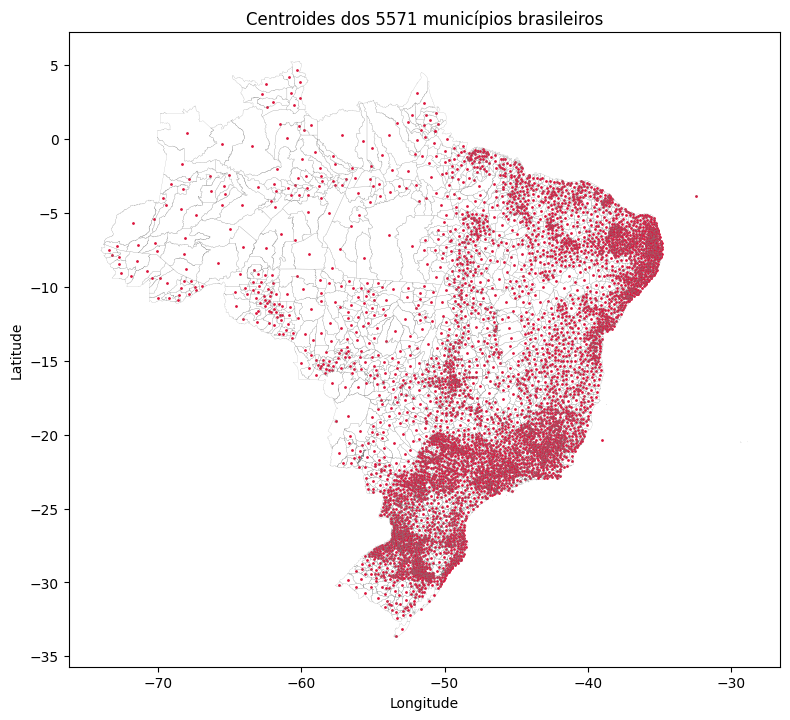

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 8))
gdf.boundary.plot(ax=ax, linewidth=0.1, color="gray")
ax.scatter(df_final["longitude"], df_final["latitude"], s=1, color="crimson")
ax.set_title(f"Centroides dos {len(df_final)} municípios brasileiros")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 9. Exportação

In [13]:
NOME_ARQUIVO = "municipios_brasil_ibge.csv"

df_final.to_csv(NOME_ARQUIVO, index=False, encoding="utf-8-sig")
print(f"Arquivo salvo: {NOME_ARQUIVO}")

# Descomente para baixar automaticamente no Colab
# from google.colab import files
# files.download(NOME_ARQUIVO)

Arquivo salvo: municipios_brasil_ibge.csv


## 10. Mapa do Brasil com os centroides municipais (estilo padrão do usuário)

Mapa em `cartopy`, seguindo a configuração usual do usuário: base do Brasil com estados delimitados, grade de coordenadas, seta norte e barra de escala. Sobre a malha municipal, plota-se um ponto em cada centroide calculado na Seção 4.

In [14]:
!pip install -q cartopy matplotlib-scalebar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 89.2 MB/s eta 0:00:00


In [15]:
import numpy as np
import math
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib_scalebar.scalebar import ScaleBar

In [16]:
# Malha municipal (já carregada na Seção 3) e malha estadual, ambas em WGS84/SIRGAS2000 (graus)
municipios_gdf = gdf
estados_gdf = geobr.read_state(year=ANO_MALHA, simplified=MALHA_SIMPLIFICADA)

/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'release-assets.githubusercontent.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
states_2025.parquet: 100%|██████████| 19.6M/19.6M [00:00<00:00, 102MB/s] 


In [17]:
def _base_map(ax, titulo):
    minx, miny, maxx, maxy = municipios_gdf.total_bounds
    dx = (maxx - minx) * 0.05; dy = (maxy - miny) * 0.05
    ax.set_extent([minx - dx, maxx + dx, miny - dy, maxy + dy], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='#F5F5F5')
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    return minx, miny, maxx, maxy

def _decoracoes(ax, minx, miny, maxx, maxy):
    estados_gdf.boundary.plot(ax=ax, edgecolor='black', linewidth=0.8,
                               transform=ccrs.PlateCarree(), zorder=5)
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 9}; gl.ylabel_style = {'size': 9}
    ax.annotate('N', xy=(0.95, 0.13), xytext=(0.95, 0.07), xycoords='axes fraction',
                textcoords='axes fraction', ha='center', va='center', fontsize=11, fontweight='bold',
                arrowprops=dict(arrowstyle='-|>', linewidth=1.3, color='black'))
    lat_media = (miny + maxy) / 2
    dx_m = 111320 * np.cos(np.deg2rad(lat_media))
    largura_km = (maxx - minx) * dx_m / 1000
    escolhas_km = [10, 20, 25, 50, 100, 150, 200, 250, 500, 750, 1000]
    fixo_km = min(escolhas_km, key=lambda x: abs(x - largura_km / 4))
    ax.add_artist(ScaleBar(dx=dx_m, units='m', fixed_value=fixo_km * 1000, location='lower left',
                            box_alpha=0.5, scale_formatter=lambda value, unit: f'{int(value/1000)} km'))

In [18]:
def plot_centroides(df_centroides, coluna_lat='latitude', coluna_lon='longitude',
                     titulo='Centroides dos Municípios Brasileiros',
                     cor_ponto='crimson', tamanho_ponto=3, savepath=None):
    """Mapa do Brasil com limites municipais e estaduais, mostrando o ponto do
    centroide de cada município. Segue o mesmo padrão visual (base, escala, seta norte,
    grade) usado nos demais mapas categóricos."""
    fig = plt.figure(figsize=(11, 11))
    ax = plt.axes([0.03, 0.03, 0.94, 0.94], projection=ccrs.PlateCarree())
    minx, miny, maxx, maxy = _base_map(ax, titulo)

    municipios_gdf.boundary.plot(ax=ax, edgecolor='#AAAAAA', linewidth=0.15,
                                  transform=ccrs.PlateCarree(), zorder=2)

    _decoracoes(ax, minx, miny, maxx, maxy)

    ax.scatter(df_centroides[coluna_lon], df_centroides[coluna_lat],
               s=tamanho_ponto, color=cor_ponto, edgecolor='none',
               transform=ccrs.PlateCarree(), zorder=6, label='Centroide municipal')

    ax.legend(loc='lower right', fontsize=9, frameon=True)
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=10)

    if savepath:
        plt.savefig(savepath, dpi=600, bbox_inches='tight')
    plt.show()

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib_scalebar/scal

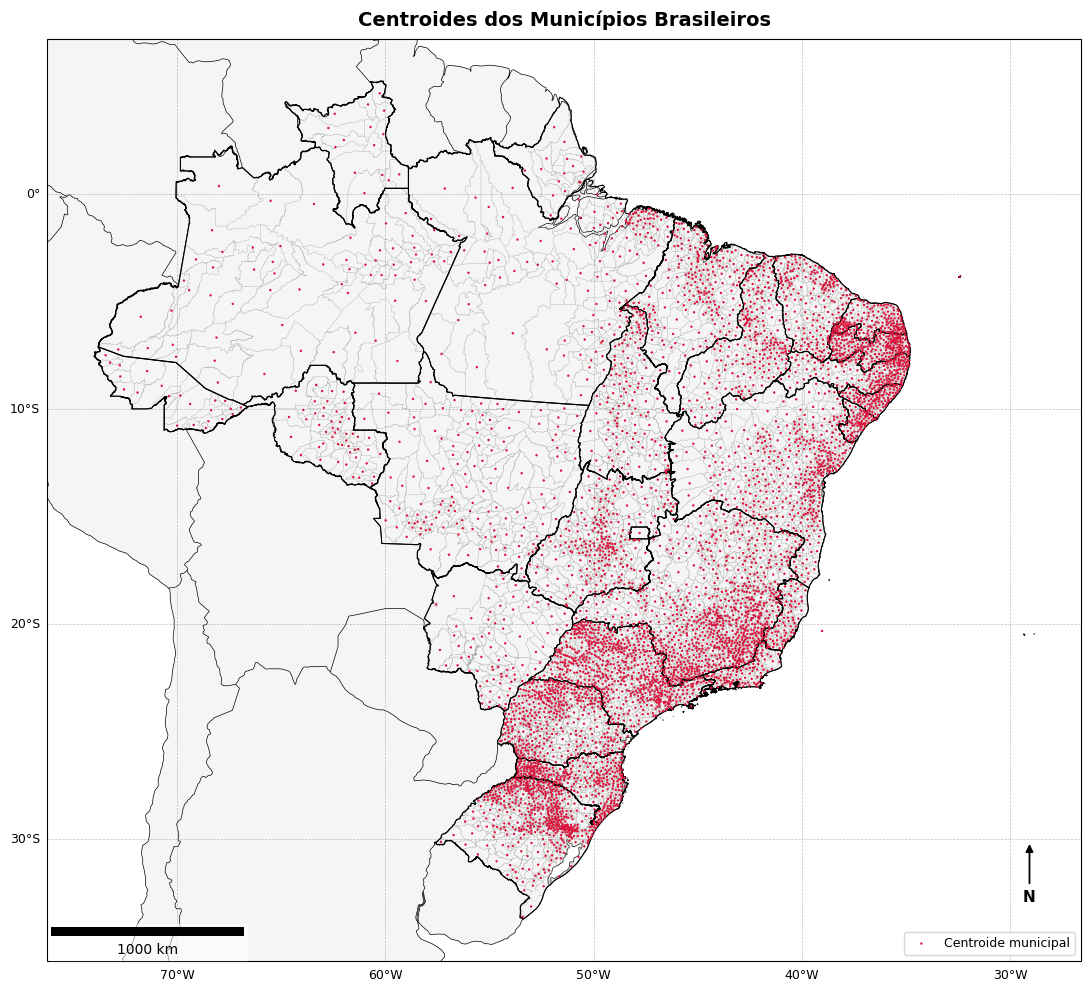

In [19]:
plot_centroides(df_final, titulo='Centroides dos Municípios Brasileiros',
                 savepath='mapa_centroides_municipios.png')